## Data Importing and Pre-processing

In [33]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

pd.set_option("display.max_columns", None)
warnings.filterwarnings("ignore", category=FutureWarning, module="pandas.*")


In [14]:
# read in file
# train file
passenger_train_df = pd.read_csv("../data/raw/train.csv")
# test file
passenger_test_df = pd.read_csv("../data/raw/test.csv")

In [15]:
# check number of rows and columns of train set
passenger_train_df.shape

(103904, 25)

In [16]:
# check number of rows and columns of test set
passenger_test_df.shape

(25976, 25)

In [17]:
# drop left over "unamed" index column
passenger_train_df.drop(columns=["Unnamed: 0", "id"], inplace=True)
passenger_test_df.drop(columns=["Unnamed: 0", "id"], inplace=True)

In [20]:
# count the number of categorical variables
cat_count = passenger_train_df.select_dtypes(include=["object", "str"]).shape[1]
print("# of categorical variables:", cat_count)

# subtract categorical and ID column from total
numeric_vars = passenger_train_df.shape[1] - cat_count
print("# of numeric variables:", numeric_vars)

# of categorical variables: 5
# of numeric variables: 18


In [21]:
passenger_train_df.head()

,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied


In [22]:
# check column names
passenger_train_df.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='str')

In [23]:
# Remove spaces from column names replace them with "_"
passenger_train_df.columns = [col.replace(" ", "_") for col in passenger_train_df.columns]
passenger_test_df.columns = [col.replace(" ", "_") for col in passenger_test_df.columns]

In [24]:
# missing data in train
total = passenger_train_df.isnull().sum().sort_values(ascending=False)
percent = (passenger_train_df.isnull().sum() / len(passenger_train_df)).sort_values(ascending=False)
missing_data_train = pd.concat([total, percent], axis=1, keys=["Total", "Percent"])
print("Train missing data:")
missing_data_train.head(10)

Train missing data:


,Total,Percent
Arrival_Delay_in_Minutes,310,0.002984
Customer_Type,0,0.000000
Gender,0,0.000000
Type_of_Travel,0,0.000000
Class,0,0.000000
Flight_Distance,0,0.000000
Age,0,0.000000
Inflight_wifi_service,0,0.000000
Departure/Arrival_time_convenient,0,0.000000
Gate_location,0,0.000000


In [25]:
# missing data in test
total = passenger_test_df.isnull().sum().sort_values(ascending=False)
percent = (passenger_test_df.isnull().sum() / len(passenger_test_df)).sort_values(ascending=False)
missing_data_test = pd.concat([total, percent], axis=1, keys=["Total", "Percent"])
print("Test missing data:")
missing_data_test.head(10)

Test missing data:


,Total,Percent
Arrival_Delay_in_Minutes,83,0.003195
Customer_Type,0,0.000000
Gender,0,0.000000
Type_of_Travel,0,0.000000
Class,0,0.000000
Flight_Distance,0,0.000000
Age,0,0.000000
Inflight_wifi_service,0,0.000000
Departure/Arrival_time_convenient,0,0.000000
Gate_location,0,0.000000


In [ ]:
# impute missing Arrival_Delay_in_Minutes with training mean for both sets to avoid test data leakage
train_mean = passenger_train_df["Arrival_Delay_in_Minutes"].mean()
passenger_train_df["Arrival_Delay_in_Minutes"] = passenger_train_df["Arrival_Delay_in_Minutes"].fillna(train_mean)
passenger_test_df["Arrival_Delay_in_Minutes"] = passenger_test_df["Arrival_Delay_in_Minutes"].fillna(train_mean)

# verify null count after imputing
print("Train nulls:", passenger_train_df.isnull().sum().sum())
print("Test nulls:", passenger_test_df.isnull().sum().sum())

Train nulls: 0
Test nulls: 0


In [28]:
# check for duplicates
print("Train duplicates:", passenger_train_df.duplicated().sum())
print("Test duplicates:", passenger_test_df.duplicated().sum())

Train duplicates: 0
Test duplicates: 0


In [29]:
# check for homogeneous categorical columns
print("Categorical Columns Mode Frequency")
cat_columns = passenger_train_df.select_dtypes(include=["object", "str"]).columns
for col in cat_columns:
    mode_value = passenger_train_df[col].mode().iat[0]
    mode_freq = (passenger_train_df[col] == mode_value).mean()
    print(f"  {col}: {mode_value} ({mode_freq:.2%})")

Categorical Columns Mode Frequency
  Gender: Female (50.75%)
  Customer_Type: Loyal Customer (81.73%)
  Type_of_Travel: Business travel (68.96%)
  Class: Business (47.80%)
  satisfaction: neutral or dissatisfied (56.67%)


In [30]:
# check for homogeneous numeric columns
print("Numeric Columns Mode Frequency")
num_columns = passenger_train_df.select_dtypes(include="number").columns
for col in num_columns:
    mode_value = passenger_train_df[col].mode().iat[0]
    mode_freq = (passenger_train_df[col] == mode_value).mean()
    print(f"  {col}: {mode_value} ({mode_freq:.2%})")

Numeric Columns Mode Frequency
  Age: 39 (2.86%)
  Flight_Distance: 337 (0.64%)
  Inflight_wifi_service: 3 (24.90%)
  Departure/Arrival_time_convenient: 4 (24.59%)
  Ease_of_Online_booking: 3 (23.53%)
  Gate_location: 3 (27.50%)
  Food_and_drink: 4 (23.44%)
  Online_boarding: 4 (29.61%)
  Seat_comfort: 4 (30.57%)
  Inflight_entertainment: 4 (28.32%)
  On-board_service: 4 (29.71%)
  Leg_room_service: 4 (27.71%)
  Baggage_handling: 4 (35.98%)
  Checkin_service: 4 (27.96%)
  Inflight_service: 4 (36.52%)
  Cleanliness: 4 (26.16%)
  Departure_Delay_in_Minutes: 0 (56.46%)
  Arrival_Delay_in_Minutes: 0.0 (55.97%)


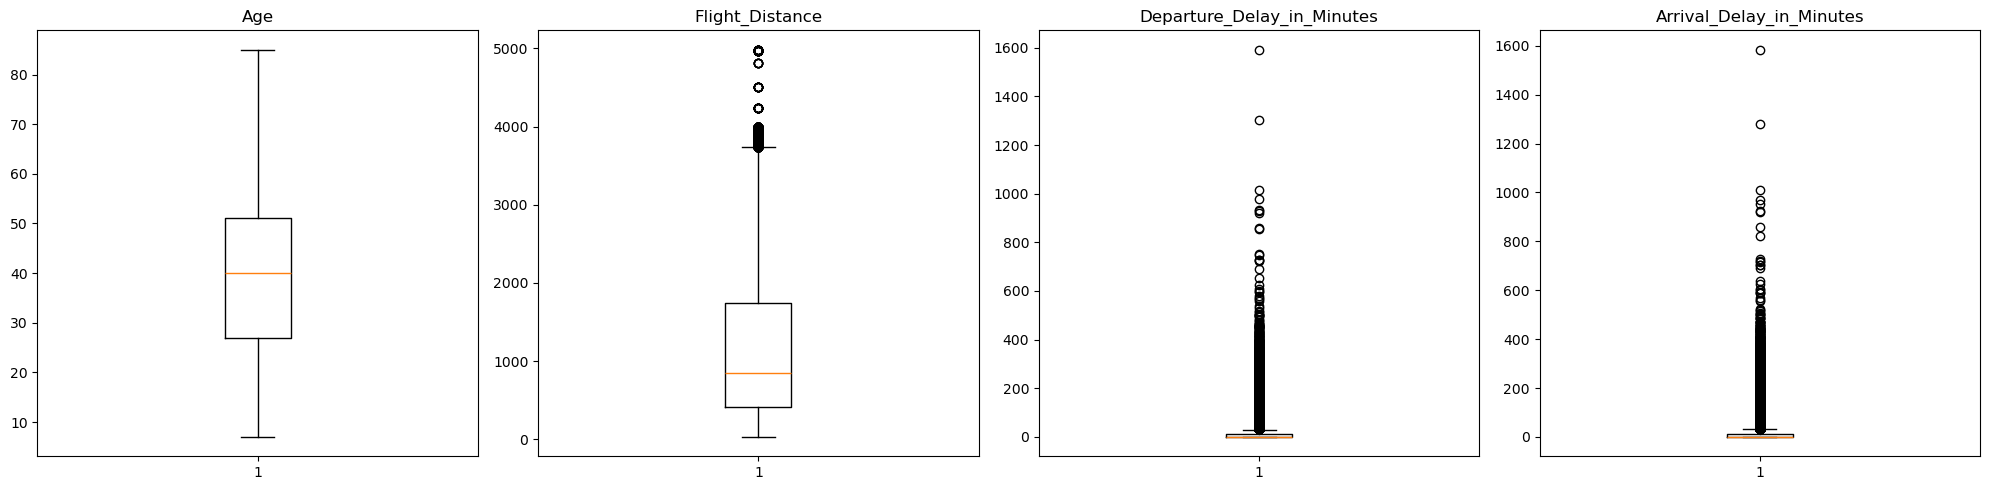

In [32]:
# check for outliers in continuous numeric columns
cols_to_check = ["Age", "Flight_Distance", "Departure_Delay_in_Minutes", "Arrival_Delay_in_Minutes"]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, col in enumerate(cols_to_check):
    axes[i].boxplot(passenger_train_df[col])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### Interpretation of outliers

flight distance outliers are legitimate data points representing long haul flights and not a typical "outlier"

as for departure delay and arrival delays the outliers were expected from the frequency check since majority of flights were not delayed. However they represent legitimate data points in the case of delays

In [34]:
# encode target variable
le_target = LabelEncoder()
passenger_train_df["satisfaction"] = le_target.fit_transform(passenger_train_df["satisfaction"])
passenger_test_df["satisfaction"] = le_target.transform(passenger_test_df["satisfaction"])
print("Target mapping:", dict(zip(le_target.classes_, le_target.transform(le_target.classes_))))

# encode binary categorical columns
binary_cols = ["Gender", "Customer_Type", "Type_of_Travel"]
for col in binary_cols:
    le = LabelEncoder()
    passenger_train_df[col] = le.fit_transform(passenger_train_df[col])
    passenger_test_df[col] = le.transform(passenger_test_df[col])
    print(f"{col} mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# ordinal encode Class (Eco < Eco Plus < Business)
class_mapping = {"Eco": 0, "Eco Plus": 1, "Business": 2}
passenger_train_df["Class"] = passenger_train_df["Class"].map(class_mapping)
passenger_test_df["Class"] = passenger_test_df["Class"].map(class_mapping)
print("Class mapping:", class_mapping)

Target mapping: {'neutral or dissatisfied': np.int64(0), 'satisfied': np.int64(1)}
Gender mapping: {'Female': np.int64(0), 'Male': np.int64(1)}
Customer_Type mapping: {'Loyal Customer': np.int64(0), 'disloyal Customer': np.int64(1)}
Type_of_Travel mapping: {'Business travel': np.int64(0), 'Personal Travel': np.int64(1)}
Class mapping: {'Eco': 0, 'Eco Plus': 1, 'Business': 2}


In [35]:
# feature engineering - apply to train and test
# total delay combines both delay columns
passenger_train_df["Total_Delay"] = passenger_train_df["Departure_Delay_in_Minutes"] + passenger_train_df["Arrival_Delay_in_Minutes"]
passenger_test_df["Total_Delay"] = passenger_test_df["Departure_Delay_in_Minutes"] + passenger_test_df["Arrival_Delay_in_Minutes"]

# average service rating across all 14 service columns
service_cols = ["Inflight_wifi_service", "Departure/Arrival_time_convenient", 
                "Ease_of_Online_booking", "Gate_location", "Food_and_drink",
                "Online_boarding", "Seat_comfort", "Inflight_entertainment",
                "On-board_service", "Leg_room_service", "Baggage_handling",
                "Checkin_service", "Inflight_service", "Cleanliness"]

passenger_train_df["Avg_Service_Rating"] = passenger_train_df[service_cols].mean(axis=1)
passenger_test_df["Avg_Service_Rating"] = passenger_test_df[service_cols].mean(axis=1)

print("New columns added. Train shape:", passenger_train_df.shape)
print("Test shape:", passenger_test_df.shape)

New columns added. Train shape: (103904, 25)
Test shape: (25976, 25)


In [36]:
# save processed data
passenger_train_df.to_csv("../data/processed/processed_train.csv", index=False)
passenger_test_df.to_csv("../data/processed/processed_test.csv", index=False)

print("Processed data saved.")
print("Train shape:", passenger_train_df.shape)
print("Test shape:", passenger_test_df.shape)

Processed data saved.
Train shape: (103904, 25)
Test shape: (25976, 25)
